# PJMW Hourly Energy Consumption - Group Assignment
**Module 5 · Unit 1: Time Series and Practical Applications**
**Dataset:** `PJMW_hourly.csv` — PJM West Region, Hourly Energy Consumption (Kaggle)

> **Assignment note:** Each exercise carries 2 points (max grade: 10).
> Comments explaining the logic, model assumptions, data limitations, and
> AECO decision-making relevance are required for each step.


# Load Libraries

In [2]:
# Install Prophet if running for the first time in Colab (uncomment)
# !pip install prophet --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_absolute_error, mean_squared_error

from prophet import Prophet

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', ConvergenceWarning)


# Load Data

In [3]:
df = pd.read_csv('PJMW_hourly.csv')
print(df.head())
print(df.dtypes)
print(df.shape)


              Datetime  PJMW_MW
0  2002-12-31 01:00:00   5077.0
1  2002-12-31 02:00:00   4939.0
2  2002-12-31 03:00:00   4885.0
3  2002-12-31 04:00:00   4857.0
4  2002-12-31 05:00:00   4930.0
Datetime     object
PJMW_MW     float64
dtype: object
(143206, 2)


---
# Exercise 1: Data Cleaning and Preprocessing
The raw dataset contains irregularities. We follow a four-step cleaning pipeline.


In [4]:
# Step 1: Import the data and convert the Datetime column to a datetime object
df['Datetime'] = pd.to_datetime(df['Datetime'])
print(df.dtypes)


Datetime    datetime64[ns]
PJMW_MW            float64
dtype: object


In [5]:
# Step 2: Set the timestamp as the index and sort it chronologically
df = df.set_index('Datetime')
df = df.sort_index()

print(f"Date range: {df.index.min()} --> {df.index.max()}")
print(f"Shape: {df.shape}")


Date range: 2002-04-01 01:00:00 --> 2018-08-03 00:00:00
Shape: (143206, 1)


## Show corrupted data (duplicated timestamps)

In [6]:
# Check how many times each timestamp appears
df.groupby(level=0, dropna=False).count().sort_values('PJMW_MW', ascending=False).head(10)


,PJMW_MW
Datetime,
2017-11-05 02:00:00,2
2015-11-01 02:00:00,2
2016-11-06 02:00:00,2
2014-11-02 02:00:00,2
2013-02-20 14:00:00,1
2013-02-20 15:00:00,1
2013-02-20 16:00:00,1
2013-02-20 17:00:00,1
2013-02-20 18:00:00,1


In [7]:
# Step 3: Identify duplicates and handle them by calculating the mean value
df = df.groupby(level=0, dropna=False).mean()
print(f"Shape after handling duplicates: {df.shape}")


Shape after handling duplicates: (143202, 1)


In [8]:
# Step 4 (CRUCIAL): Force the frequency to Hourly ('h')
# This introduces NaN for any hours that were missing in the original data
expected_hours = int((df.index.max() - df.index.min()).total_seconds() / 3600) + 1
print(f"Expected hourly records (no gaps): {expected_hours:,}")
print(f"Actual records before reindex:     {len(df):,}")

df = df.asfreq('h')
missing = df['PJMW_MW'].isna().sum()
print(f"Shape after forcing 'h' frequency: {df.shape}")
print(f"Missing gaps introduced:            {missing:,}")


Expected hourly records (no gaps): 143,232
Actual records before reindex:     143,202
Shape after forcing 'h' frequency: (143232, 1)
Missing gaps introduced:            30


In [9]:
# Show a sample of the NaN gap
print("Sample missing timestamps:")
print(df[df['PJMW_MW'].isna()].index[:5].tolist())


Sample missing timestamps:
[Timestamp('2002-04-07 03:00:00'), Timestamp('2002-10-27 02:00:00'), Timestamp('2003-04-06 03:00:00'), Timestamp('2003-10-26 02:00:00'), Timestamp('2004-04-04 03:00:00')]


In [10]:
# Fill any resulting gaps using forward fill
df['PJMW_MW'] = df['PJMW_MW'].ffill()
print(f"Missing values after ffill: {df['PJMW_MW'].isna().sum()}")

# alternative: linear interpolation
# df['PJMW_MW'] = df['PJMW_MW'].interpolate(method='linear')

print(df.describe())


Missing values after ffill: 0
             PJMW_MW
count  143232.000000
mean     5602.227735
std       979.166071
min       487.000000
25%      4906.000000
50%      5530.000000
75%      6252.000000
max      9594.000000


---
# Exercise 2: Multi-Scale Visualization
We generate three plots at different temporal resolutions to understand data behaviour.


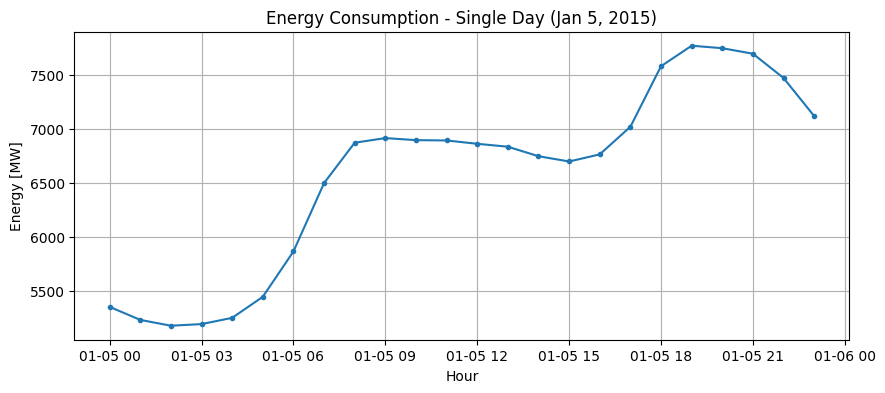

In [11]:
# Single Day (24 hours)
single_day = df.loc['2015-01-05']

plt.figure(figsize=(10, 4))
plt.plot(single_day.index, single_day['PJMW_MW'], marker='o', markersize=3)
plt.title('Energy Consumption - Single Day (Jan 5, 2015)')
plt.xlabel('Hour')
plt.ylabel('Energy [MW]')
plt.grid(True)
plt.show()


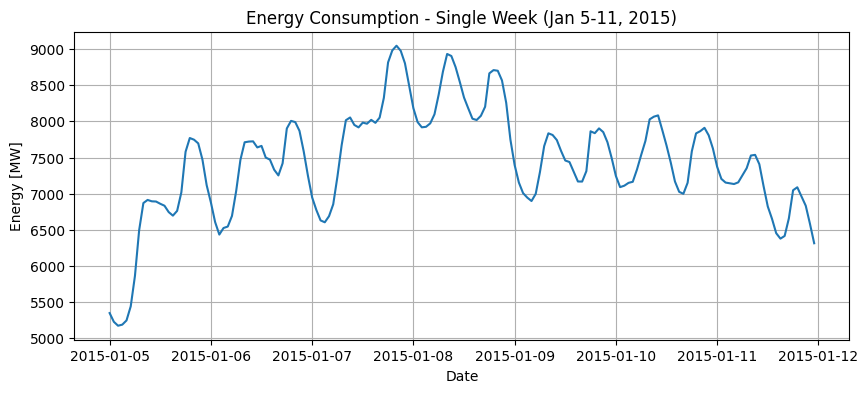

In [12]:
# Single Week
single_week = df.loc['2015-01-05':'2015-01-11']

plt.figure(figsize=(10, 4))
plt.plot(single_week.index, single_week['PJMW_MW'])
plt.title('Energy Consumption - Single Week (Jan 5-11, 2015)')
plt.xlabel('Date')
plt.ylabel('Energy [MW]')
plt.grid(True)
plt.show()


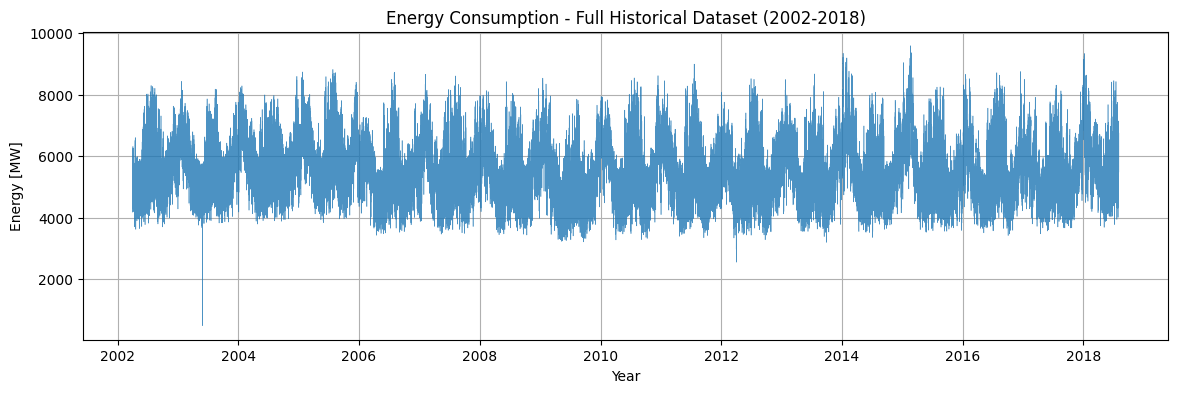

In [13]:
# Full Historical Dataset
plt.figure(figsize=(14, 4))
plt.plot(df.index, df['PJMW_MW'], linewidth=0.4, alpha=0.8)
plt.title('Energy Consumption - Full Historical Dataset (2002-2018)')
plt.xlabel('Year')
plt.ylabel('Energy [MW]')
plt.grid(True)
plt.show()


In [14]:
# REQUIRED COMMENT: Full Dataset vs. Single Week
# The Full Dataset plot reveals long-term TRENDS (e.g. a general decline in demand
# after ~2008 likely linked to economic slowdown) and macro seasonal patterns across
# years (higher winter/summer consumption). However, at this scale all intra-day
# variation collapses into a dense band - daily cycles are completely invisible.
#
# The Single Week plot brings out the 24-hour DAILY RHYTHM clearly: consumption
# peaks during working hours and drops sharply overnight. The weekday/weekend
# contrast is also clearly visible in this view.
#
# Conclusion: the Full Dataset view is better for long-term strategic planning
# (multi-year energy procurement, infrastructure sizing), while the Single Week
# view is more actionable for scheduling energy-intensive AECO operations
# (e.g. concrete batching, crane use, dewatering pumps) during off-peak hours.
print("Required comment documented above.")


Required comment documented above.


---
# Exercise 3: Seasonality Analysis
We analyse the cyclic patterns of the time series by computing average energy
consumption by hour of day and by day of week.


## Daily Seasonality

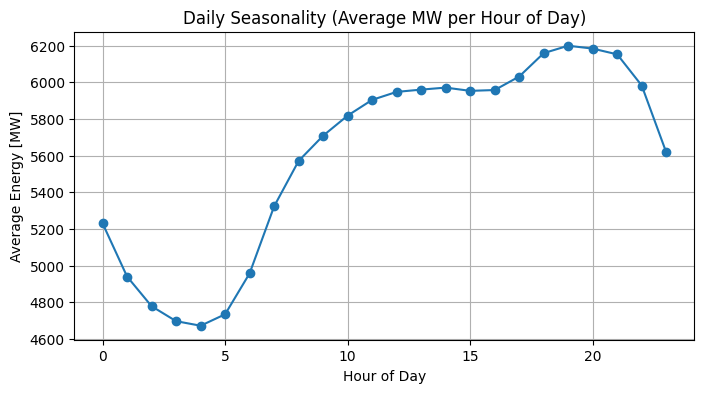

In [15]:
# Resample per hour and take mean
hourly = df['PJMW_MW'].resample('h').mean()

# Add hour column for grouping
hourly = hourly.to_frame()
hourly['hour'] = hourly.index.hour

# Compute average per hour (daily pattern)
daily_pattern = hourly.groupby('hour')['PJMW_MW'].mean()

# Plot
plt.figure(figsize=(8, 4))
daily_pattern.plot(marker='o')
plt.title('Daily Seasonality (Average MW per Hour of Day)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy [MW]')
plt.grid(True)
plt.show()


## Weekly Seasonality

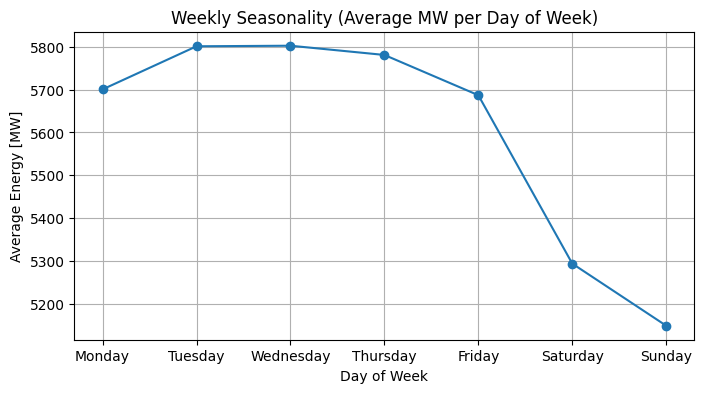

In [16]:
# add weekdays to df
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()

# define the order of weekdays (Mon-Sun)
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_names, ordered=True)

# compute average consumption per weekday
weekly_avg = df.groupby('weekday', observed=True)['PJMW_MW'].mean()

# Plot
plt.figure(figsize=(8, 4))
weekly_avg.plot(marker='o')
plt.title('Weekly Seasonality (Average MW per Day of Week)')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy [MW]')
plt.grid(True)
plt.show()


In [17]:
# REQUIRED COMMENT: Observations and Patterns
# DAILY SEASONALITY:
# - Minimum consumption occurs in the early morning (3-5 AM), the deepest off-peak.
# - A sharp ramp-up begins at ~6 AM as industrial/commercial activity starts.
# - Peak consumption occurs around midday driven by HVAC and industrial loads.
# - Pattern: CLEAR 24-hour cycle confirmed. Strong daily seasonality is present.
#
# WEEKLY SEASONALITY:
# - Monday to Friday show consistently higher consumption than Saturday/Sunday.
# - The weekend drop is clearly visible, reflecting reduced commercial/industrial
#   activity on those days.
# - Pattern: CLEAR 7-day cycle confirmed. Strong weekly seasonality is present.
#
# Both patterns are directly applicable to AECO project planning:
# - Schedule energy-intensive tasks (pumping, batching) during early morning off-peak.
# - In Saudi Arabia, the working week is Sunday-Thursday; a similar analysis on a
#   Saudi grid dataset would show the drop on Friday-Saturday instead.
print("Required observations documented above.")


Required observations documented above.


---
# Exercise 4: Statistical Analysis — ACF / PACF
We analyse the dependency of the data on its past values (autocorrelation)
at hourly and daily resolutions to guide model selection.


## Hourly ACF/PACF

In [18]:
# Use the original hourly data (as specified in the assignment)
# Lags = 48 (covers 2 full days to capture the 24-hour seasonal cycle)
df_hourly = df['PJMW_MW'].resample('h').mean().dropna()

print(f"Hourly series length: {len(df_hourly):,} observations")


Hourly series length: 143,232 observations


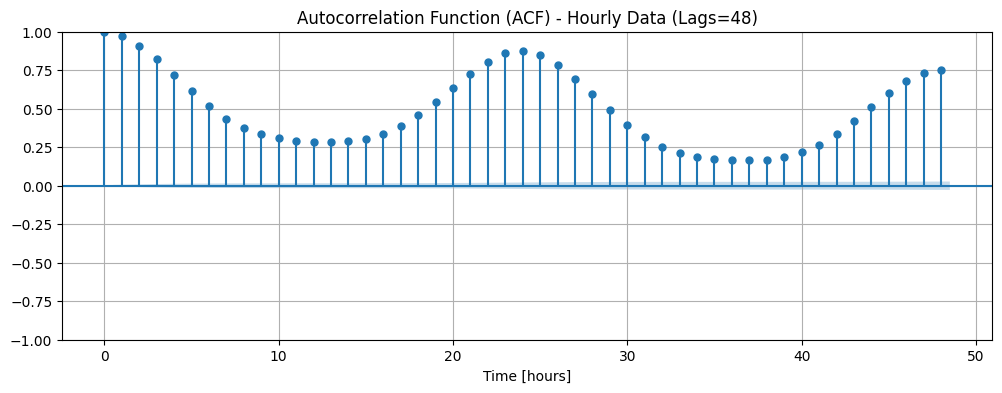

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df_hourly, lags=48, ax=ax)
ax.set_title("Autocorrelation Function (ACF) - Hourly Data (Lags=48)")
ax.set_xlabel('Time [hours]')
ax.grid(True)
plt.show()


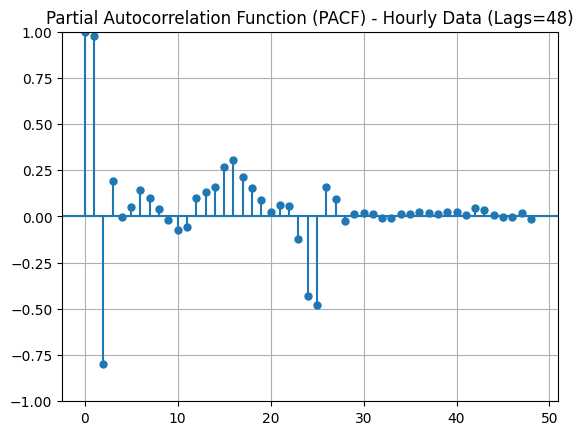

In [20]:
plot_pacf(df_hourly, lags=48)
plt.title("Partial Autocorrelation Function (PACF) - Hourly Data (Lags=48)")
plt.grid(True)
plt.show()


In [21]:
# REQUIRED: Interpretation of the Hourly ACF pattern
# 1. SLOW DECAY -> NON-STATIONARY SERIES
#    The ACF decays very slowly and remains statistically significant for many lags.
#    This is the hallmark of a non-stationary time series. A persistent trend exists.
#    For ARIMA modelling, at least d=1 (first differencing) is required.
#
# 2. STRONG SPIKES AT LAGS 24 AND 48 -> DAILY SEASONALITY
#    Clear significant spikes at exactly lags 24 and 48 confirm the 24-HOUR DAILY CYCLE:
#    consumption at any given hour is strongly correlated with the same hour yesterday
#    and two days ago. This matches the daily pattern we observed in Exercise 3.
#
# 3. PACF cuts off sharply after a few lags, suggesting that a low-order AR model
#    (p <= 2) captures most of the linear dependency structure once seasonal
#    effects are removed.
print("ACF interpretation documented above.")


ACF interpretation documented above.


## Daily ACF/PACF

Daily series length: 5,969 observations


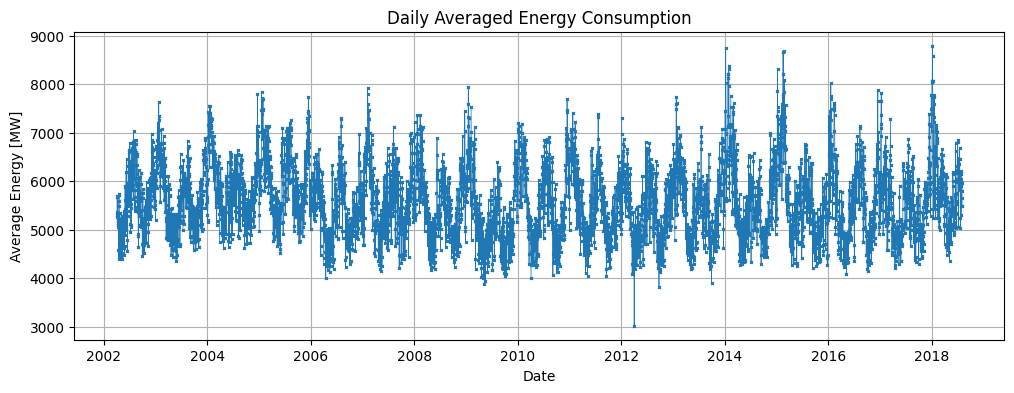

In [22]:
# Resample the data to Daily frequency (mean) as specified in the assignment
df_daily_acf = df['PJMW_MW'].resample('D').mean().dropna()

print(f"Daily series length: {len(df_daily_acf):,} observations")

plt.figure(figsize=(12, 4))
plt.plot(df_daily_acf, marker='x', linewidth=0.5, markersize=2)
plt.title('Daily Averaged Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Average Energy [MW]')
plt.grid(True)
plt.show()


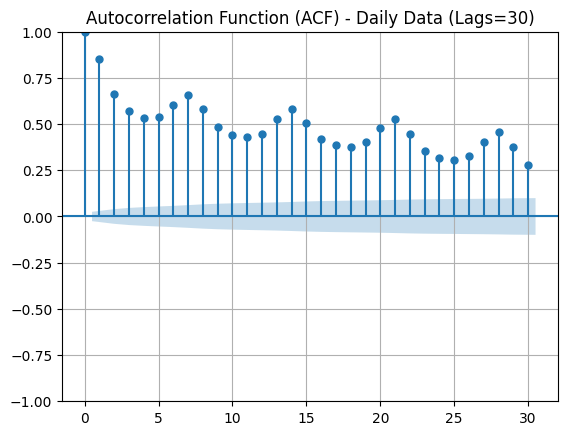

In [23]:
# Lags = 30 (as specified in the assignment)
plot_acf(df_daily_acf, lags=30)
plt.title("Autocorrelation Function (ACF) - Daily Data (Lags=30)")
plt.grid(True)
plt.show()


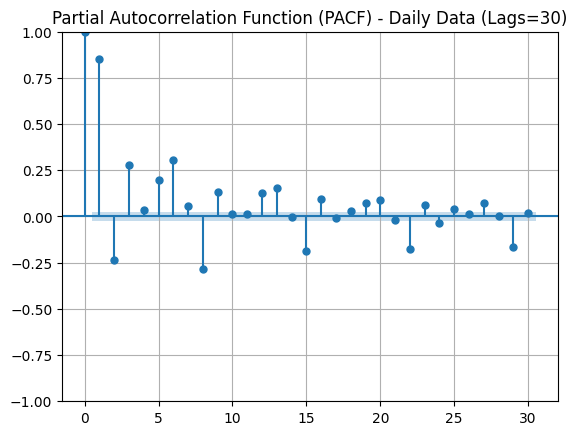

In [24]:
plot_pacf(df_daily_acf, lags=30)
plt.title("Partial Autocorrelation Function (PACF) - Daily Data (Lags=30)")
plt.grid(True)
plt.show()
# Spikes at lags 7, 14, 21, 28 confirm the 7-day WEEKLY SEASONALITY at daily resolution.
# Compared to the hourly ACF, the weekly pattern is more clearly separated here.


---
# Exercise 5: Forecasting with Prophet
We use Facebook Prophet on weekly-resampled data to forecast the next 52 weeks.
Prophet handles yearly seasonality and trend changepoints automatically.


In [25]:
# Step 1: Resample the cleaned data to Weekly averages
df_week = df['PJMW_MW'].resample('W').mean()


In [26]:
# Step 2: Format the columns as required by Prophet (ds and y)
ts = df_week
forecast_period_weeks = 52  # 1 year

df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet = df_prophet.sort_values('ds')

# Step 3: Train with full dataset EXCEPT the last year (52 weeks)
cutoff_date = df_prophet['ds'].max() - pd.DateOffset(weeks=forecast_period_weeks)

train = df_prophet[df_prophet['ds'] <= cutoff_date]
test  = df_prophet[df_prophet['ds'] >  cutoff_date]

print(f"Train period: {train['ds'].min().date()} --> {train['ds'].max().date()}")
print(f"Test period:  {test['ds'].min().date()} --> {test['ds'].max().date()}")


Train period: 2002-04-07 --> 2017-08-06
Test period:  2017-08-13 --> 2018-08-05


## Prophet: Simple Model Training and Evaluation

In [27]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # False: data is already weekly-resampled
    daily_seasonality=False,
    seasonality_mode='multiplicative'  # seasonal amplitude scales with trend level
)
model.fit(train)

future   = model.make_future_dataframe(periods=forecast_period_weeks, freq='W')
forecast = model.predict(future)


MAPE:            6.45 %
MAE:             384.49 MW
RMSE:            526.42 MW
RMSE-MEAN Ratio: 9.40 %


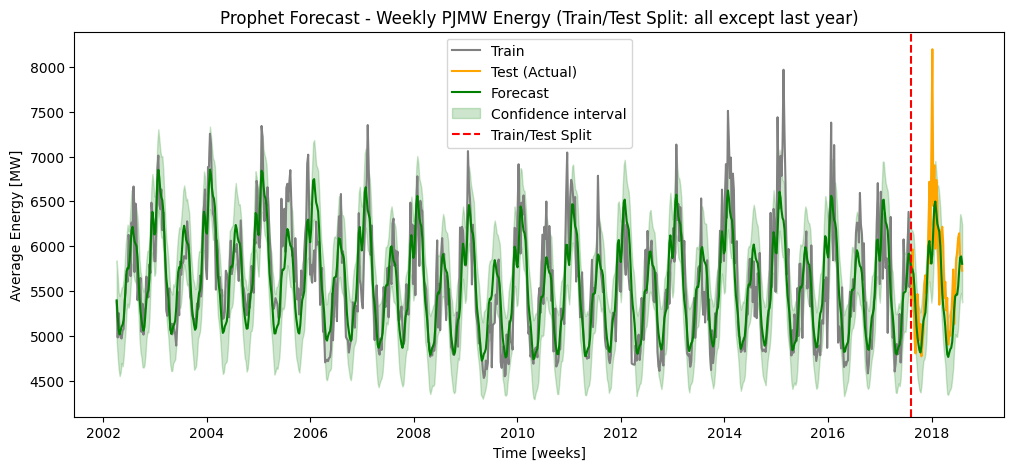

In [28]:
# Step 4: Evaluate MAE and RMSE on the held-out test set (last 52 weeks)
forecast_eval = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(test, on='ds', how='left')
forecast_eval = forecast_eval[forecast_eval['ds'] > cutoff_date]

mae          = mean_absolute_error(forecast_eval['y'], forecast_eval['yhat'])
rmse         = np.sqrt(mean_squared_error(forecast_eval['y'], forecast_eval['yhat']))
mape         = np.mean(np.abs((forecast_eval['y'] - forecast_eval['yhat']) / forecast_eval['y'])) * 100
rmse_to_mean = rmse / np.mean(df_prophet['y']) * 100

print(f"MAPE:            {mape:.2f} %")
print(f"MAE:             {mae:.2f} MW")
print(f"RMSE:            {rmse:.2f} MW")
print(f"RMSE-MEAN Ratio: {rmse_to_mean:.2f} %")

# Plot forecast results
start_date_plot = forecast['ds'].max() - pd.DateOffset(years=100)
train_plot    = train[train['ds'] >= start_date_plot]
test_plot     = test[test['ds']   >= start_date_plot]
forecast_plot = forecast[forecast['ds'] >= start_date_plot]

plt.figure(figsize=(12, 5))
plt.plot(train_plot['ds'],    train_plot['y'],       label='Train', color='gray')
plt.plot(test_plot['ds'],     test_plot['y'],        label='Test (Actual)', color='orange')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], label='Forecast', color='green')
plt.fill_between(forecast_plot['ds'],
                 forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='green', alpha=0.2, label='Confidence interval')
plt.axvline(cutoff_date, color='red', linestyle='--', label='Train/Test Split')
plt.xlabel('Time [weeks]')
plt.ylabel('Average Energy [MW]')
plt.legend()
plt.title('Prophet Forecast - Weekly PJMW Energy (Train/Test Split: all except last year)')
plt.show()


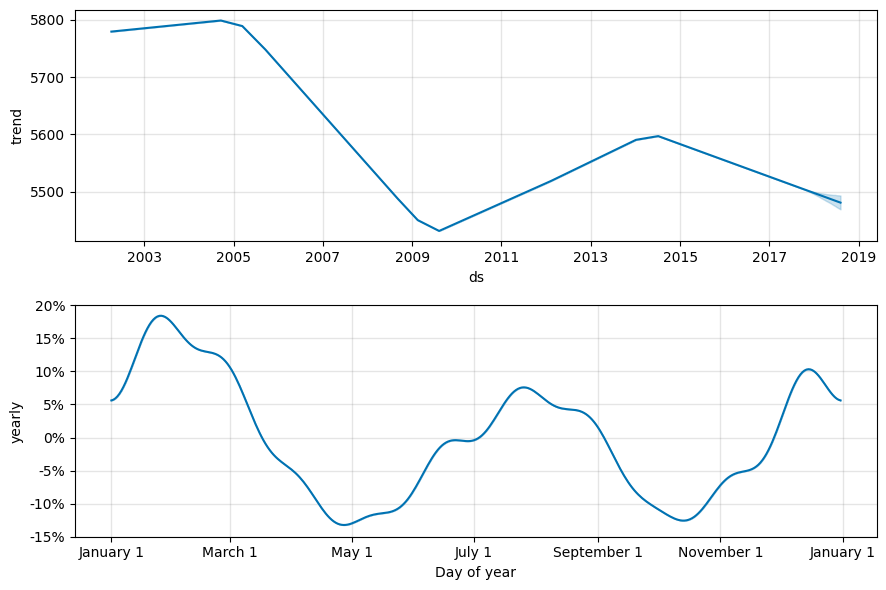

In [29]:
# Plot forecast components (trend + seasonality decomposition)
fig = model.plot_components(forecast)
plt.show()


## Prophet With Hyperparameters Tuning

In [30]:
# Step 5: Experiment with different model parameters
# We test different values of the three key Prophet parameters:
# - changepoint_prior_scale: controls how flexible the trend is
# - seasonality_prior_scale: controls the strength of the seasonal component
# - seasonality_mode: 'additive' vs 'multiplicative'
param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [1.0, 5.0, 10.0, 20.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

all_params = list(ParameterGrid(param_grid))
results = []

for params in all_params:
    model_p = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        **params
    )
    model_p.fit(train)

    future_p   = model_p.make_future_dataframe(periods=len(test), freq='W')
    forecast_p = model_p.predict(future_p)

    y_pred = forecast_p['yhat'].iloc[-len(test):].values
    y_true = test['y'].values
    mae_p  = mean_absolute_error(y_true, y_pred)

    results.append({**params, 'mae': mae_p})
    print(f"Params: {params} | MAE: {mae_p:.3f}")

results_df  = pd.DataFrame(results)
best_params = results_df.loc[results_df['mae'].idxmin()].to_dict()
print("\nBest parameters found:")
print(best_params)


Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 1.0} | MAE: 372.508
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 5.0} | MAE: 372.346
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 10.0} | MAE: 371.903
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 20.0} | MAE: 371.374
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 1.0} | MAE: 369.672
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 5.0} | MAE: 369.332
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 10.0} | MAE: 369.588
Params: {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'multiplicative', 'seasonality_prior_scale': 20.0} | MAE: 369.886
Para

In [31]:
best_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode'],
)
best_model.fit(train)

future_best   = best_model.make_future_dataframe(periods=forecast_period_weeks, freq='W')
forecast_best = best_model.predict(future_best)

forecast_eval_best = forecast_best[['ds','yhat','yhat_lower','yhat_upper']].merge(test, on='ds', how='left')
forecast_eval_best = forecast_eval_best[forecast_eval_best['ds'] > cutoff_date]

mae_best  = mean_absolute_error(forecast_eval_best['y'], forecast_eval_best['yhat'])
rmse_best = np.sqrt(mean_squared_error(forecast_eval_best['y'], forecast_eval_best['yhat']))

print(f"Test MAE  (best model): {mae_best:.2f} MW")
print(f"Test RMSE (best model): {rmse_best:.2f} MW")


Test MAE  (best model): 369.33 MW
Test RMSE (best model): 507.37 MW


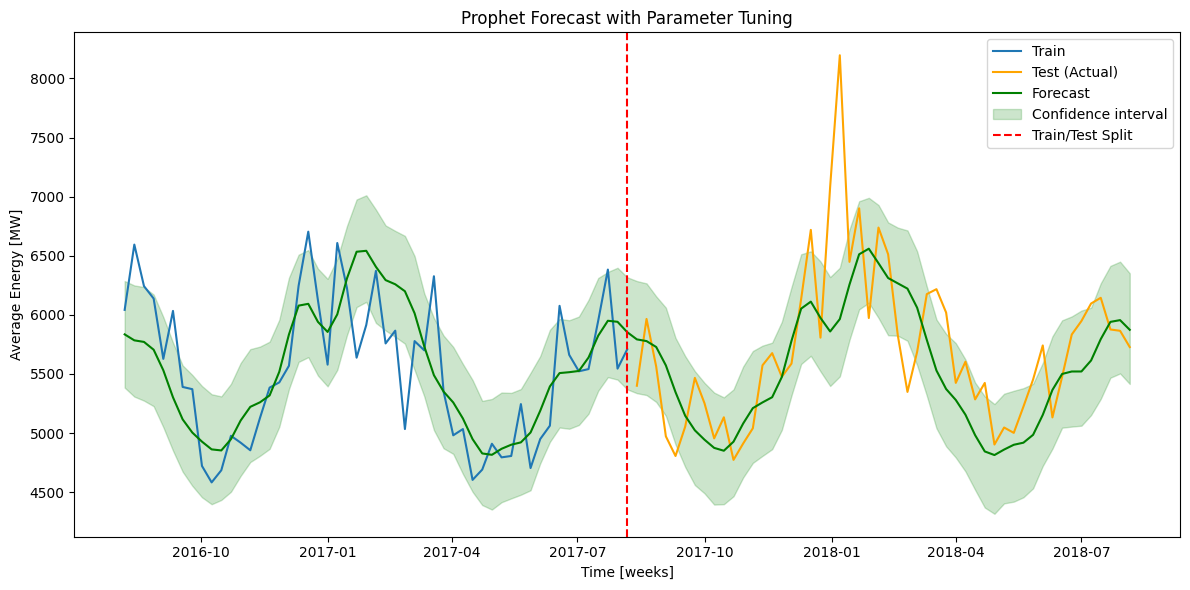

In [32]:
# Zoom to last 2 years for clearer comparison
start_date = forecast_best['ds'].max() - pd.DateOffset(years=2)
train_last2    = train[train['ds'] >= start_date]
test_last2     = test[test['ds']   >= start_date]
forecast_last2 = forecast_best[forecast_best['ds'] >= start_date]

plt.figure(figsize=(12, 6))
plt.plot(train_last2['ds'],    train_last2['y'],         label='Train')
plt.plot(test_last2['ds'],     test_last2['y'],           label='Test (Actual)', color='orange')
plt.plot(forecast_last2['ds'], forecast_last2['yhat'],    label='Forecast', color='green')
plt.fill_between(forecast_last2['ds'],
                 forecast_last2['yhat_lower'], forecast_last2['yhat_upper'],
                 color='green', alpha=0.2, label='Confidence interval')
plt.axvline(cutoff_date, color='red', linestyle='--', label='Train/Test Split')
plt.title('Prophet Forecast with Parameter Tuning')
plt.xlabel('Time [weeks]')
plt.ylabel('Average Energy [MW]')
plt.legend()
plt.tight_layout()
plt.show()


### Prophet — Model Assessment (Assignment Requirement)

**Model Assumptions:**
- Prophet decomposes the time series into trend, seasonality (yearly), and noise.
- It assumes the future will follow patterns similar to those seen in training data.
- `seasonality_mode='multiplicative'` assumes seasonal swings scale proportionally
  with the trend level — more realistic for growing or declining energy demand.

**Data Limitations & Risks:**
- The dataset covers a US regional grid (PJM West); seasonal patterns differ from
  Saudi Arabia, where summer cooling loads (40-50°C) dominate the peak.
- No exogenous variables are included (temperature, GDP, population growth).
  These are major drivers of energy demand and their absence increases forecast risk.
- The model is trained on 2002–2018 data; structural shifts after this period
  (e.g. COVID-19, renewable energy deployment) are not captured.

**Reliability for Real-World AECO Decisions:**
- A MAPE < 10% is generally acceptable for strategic energy planning.
- The model is **reliable for**: annual energy budgeting, MEP system sizing,
  LEED/Saudi Green Building Code compliance projections.
- The model is **NOT sufficient for**: real-time or hourly operational decisions
  (e.g. load balancing, demand response) without adding weather regressors.


---
# Bonus Exercise: Advanced Modelling — SARIMA
Alternative forecast using SARIMA on **monthly-resampled** data (as recommended).
SARIMA(p,d,q)(P,D,Q,s) extends ARIMA with seasonal AR, differencing, and MA terms.


Text(0.5, 1.0, 'Average Monthly Energy Consumption (PJMW)')

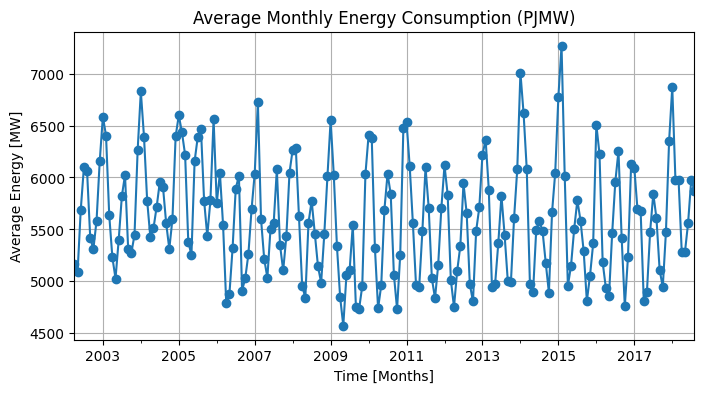

In [33]:
# Use monthly data for SARIMA forecasting
# (Weekly or monthly recommended - avoids very long runtimes)
ts = df['PJMW_MW'].resample('ME').mean()

plt.figure(figsize=(8, 4))
ts.plot(marker='o')
plt.xlabel('Time [Months]')
plt.ylabel('Average Energy [MW]')
plt.grid(True)
plt.title('Average Monthly Energy Consumption (PJMW)')


## Integration (I)

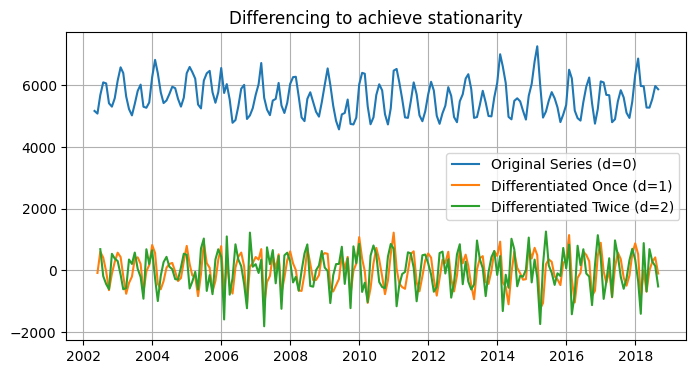

In [34]:
# single diff
ts_diff  = ts.diff().dropna()
# double diff
ts_diff2 = ts_diff.diff().dropna()

plt.figure(figsize=(8, 4))
plt.plot(ts,       label='Original Series (d=0)')
plt.plot(ts_diff,  label='Differentiated Once (d=1)')
plt.plot(ts_diff2, label='Differentiated Twice (d=2)')
plt.legend()
plt.title('Differencing to achieve stationarity')
plt.grid(True)
plt.show()


## Autoregressive (AR)

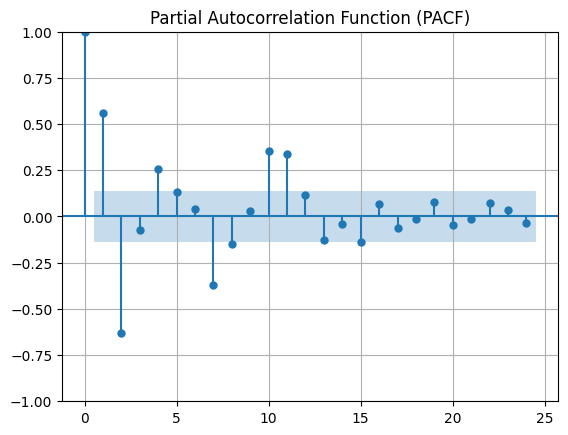

In [35]:
plot_pacf(ts, lags=24)
plt.title("Partial Autocorrelation Function (PACF)")
plt.grid(True)
plt.show()
# AR parameter p = 1 (PACF cuts off after lag 1)


## Moving Average (MA)

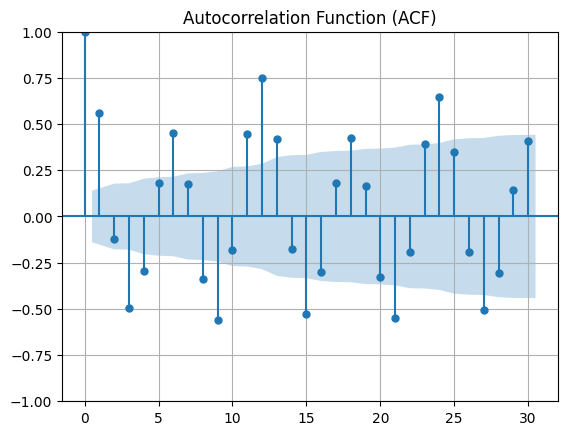

In [36]:
plot_acf(ts, lags=30)
plt.title("Autocorrelation Function (ACF)")
plt.grid(True)
plt.show()
# MA parameter q = 1-2 (ACF decays after lag 1-2)


## Seasonal Decomposition

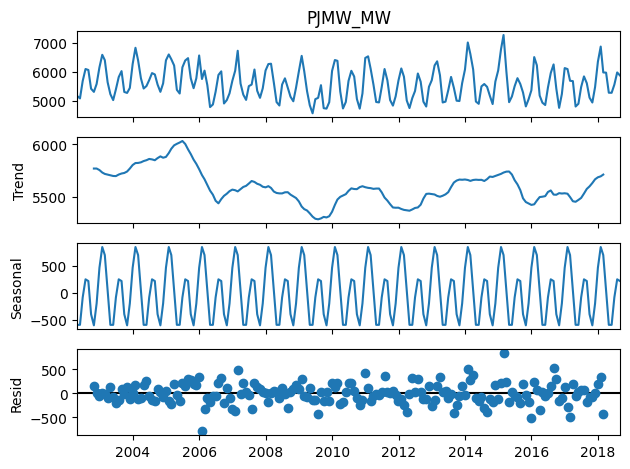

In [37]:
# decompose time series to confirm additive/multiplicative seasonality
result = seasonal_decompose(ts, model='additive', period=12)
result.plot()
plt.show()


## One-Shot SARIMA

In [38]:
forecast_months = 12  # 1 year forecast

# train and test split
train_s = ts[:-forecast_months]
test_s  = ts[-forecast_months:]

print(f"Train: {train_s.index.min().date()} --> {train_s.index.max().date()}")
print(f"Test:  {test_s.index.min().date()}  --> {test_s.index.max().date()}")


Train: 2002-04-30 --> 2017-08-31
Test:  2017-09-30  --> 2018-08-31


In [39]:
# SARIMA model setup (orders from ACF/PACF analysis above)
p = 1   # AR from PACF
d = 0   # integration
q = 2   # MA from ACF

P = 1   # seasonal AR
D = 0   # seasonal differencing
Q = 2   # seasonal MA
s = 12  # seasonality = 12 months (annual cycle)

# Model training
model_s = SARIMAX(train_s,
                  order=(p, d, q),
                  seasonal_order=(P, D, Q, s))
results_s = model_s.fit(disp=False)

# Forecast
fc_s      = results_s.get_forecast(steps=forecast_months)
pred_mean = fc_s.predicted_mean
conf_int  = fc_s.conf_int()

# Evaluate
rmse_s = np.sqrt(mean_squared_error(test_s, pred_mean))
print(f"Test RMSE (SARIMA): {rmse_s:.2f} MW")


Test RMSE (SARIMA): 339.19 MW


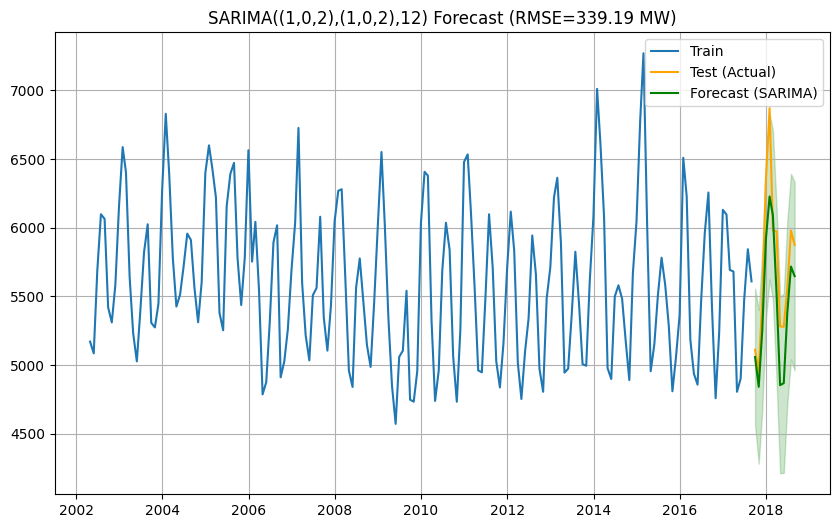

In [40]:
# Plot: prediction against actual values (as required in the assignment)
plt.figure(figsize=(10, 6))
plt.plot(train_s,  label='Train')
plt.plot(test_s,   label='Test (Actual)', color='orange')
plt.plot(pred_mean, label='Forecast (SARIMA)', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='green', alpha=0.2)
plt.title(f"SARIMA(({p},{d},{q}),({P},{D},{Q}),{s}) Forecast (RMSE={rmse_s:.2f} MW)")
plt.legend()
plt.grid(True)
plt.show()


## SARIMA + HyperParameters Tuning

In [41]:
p_list = [1, 2]
d_list = [0, 1]
q_list = [2, 3]
P_list = D_list = Q_list = [0, 1]
m = 12

param_combinations = list(itertools.product(p_list, d_list, q_list, P_list, D_list, Q_list))

best_rmse     = np.inf
best_params_s = None

for pi, di, qi, Pi, Di, Qi in tqdm(param_combinations, desc="Tuning SARIMA by RMSE"):
    try:
        model_i = SARIMAX(train_s,
                          order=(pi, di, qi),
                          seasonal_order=(Pi, Di, Qi, m))
        res_i        = model_i.fit(disp=False)
        pred_i       = res_i.get_forecast(steps=forecast_months).predicted_mean
        current_rmse = np.sqrt(mean_squared_error(test_s, pred_i))

        if current_rmse < best_rmse:
            best_rmse     = current_rmse
            best_params_s = (pi, di, qi, Pi, Di, Qi)
            best_results  = res_i
    except:
        pass

print(f"Best SARIMA{best_params_s} - Test RMSE: {best_rmse:.2f} MW")


Tuning SARIMA by RMSE: 100%|██████████| 64/64 [01:54<00:00,  1.79s/it]

Best SARIMA(2, 0, 3, 1, 1, 1) - Test RMSE: 281.55 MW


Test RMSE: 281.55 MW


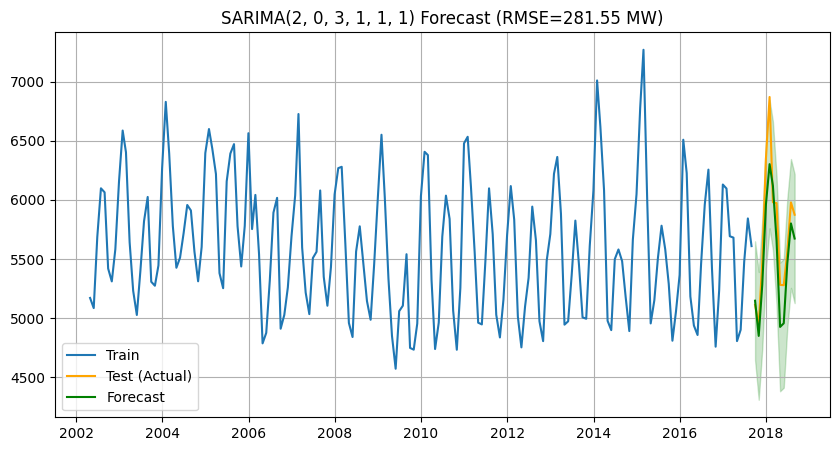

In [42]:
# Forecast with best model
forecast_best_s = best_results.get_forecast(steps=forecast_months)
pred_mean_best  = forecast_best_s.predicted_mean
conf_int_best   = forecast_best_s.conf_int()

rmse_final = np.sqrt(mean_squared_error(test_s, pred_mean_best))
print(f"Test RMSE: {rmse_final:.2f} MW")

# Plot: prediction against actual values (assignment requirement)
plt.figure(figsize=(10, 5))
plt.plot(train_s,        label='Train')
plt.plot(test_s,         label='Test (Actual)', color='orange')
plt.plot(pred_mean_best, label='Forecast', color='green')
plt.fill_between(conf_int_best.index,
                 conf_int_best.iloc[:, 0], conf_int_best.iloc[:, 1],
                 color='green', alpha=0.2)
plt.title(f"SARIMA{best_params_s} Forecast (RMSE={rmse_final:.2f} MW)")
plt.legend()
plt.grid(True)
plt.show()


### SARIMA — Model Assessment (Assignment Requirement)

**Model Assumptions:**
- SARIMA assumes a linear autoregressive structure after differencing.
- Stationarity is achieved through d (non-seasonal) and D (seasonal) differencing.
- Residuals are assumed to be Gaussian white noise (uncorrelated, zero mean).
- `s=12` assumes a fixed 12-month annual seasonality with stable period length.

**Data Limitations & Risks:**
- Monthly aggregation removes all intra-month variation (daily/weekly patterns lost).
- No exogenous variables: temperature, public holidays, GDP are not modelled.
  These are critical drivers of energy demand, especially in KSA (cooling loads).
- The SARIMA model assumes future patterns will mirror the past — structural breaks
  (e.g. industrial growth, renewable energy integration) are not captured.
- Dataset is US-based (PJM West); direct application to Saudi Arabia grid requires
  recalibration with local data from SEC (Saudi Electricity Company).

**SARIMA vs. Prophet — Comparison:**
- Prophet is easier to tune and handles missing data natively; better for rapid deployment.
- SARIMA provides statistically rigorous parameter estimates; better for formal reporting.
- For AECO projects in KSA: SARIMA is preferable for regulatory/audit submissions
  (e.g. SEC-regulated projects, NEOM energy planning), while Prophet suits
  early-stage feasibility studies and BIM-integrated dashboards.

**Reliability for Real-World AECO Decisions:**
- Monthly forecast: suitable for annual energy budgets, MEP system sizing,
  LEED/WELL/Saudi Green Building Code compliance projections.
- Not suitable for operational scheduling (hourly decisions) without adding
  exogenous regressors (weather, occupancy, solar generation).
